# Potential Energy and Equilibrium Structure

## Overview
**Questions**
- How do I predict the equilibrium lattice constants for a material?
- How do I attach a calculator to an `Atoms` object?
- What properties can a calculator compute?
- How can I store results so that they are easy to search and retrieve?

**Objectives**
- Attach an EMT calculator and compute energy, forces, and stress
- Use an Equation of State to predict equilibrium lattice constants
- Understand the calculator interface
- Store results using ASE databases

**Key Points**
- Attach a calculator with `atoms.calc = Calculator()`
- `get_potential_energy()`, `get_forces()`, `get_stress()` trigger calculations
- The equation of state gives equilibrium lattice constant and bulk modulus
- Use `ase.db` to store and query results

## Lecture Slides

The slides for this tutorial are embedded below.
[📥 Download slides (.pptx)](https://github.com/NU-CEM/Atomistic_Simulation/raw/2026/slides/Tutorial2_MaterialsBasics.pptx) &nbsp;|&nbsp; [Open in full screen](https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={2624b845-8876-44a6-8741-950ce2d6f40e}&amp;action=embedview&amp;wdAr=1.7777777777777777)

<iframe
  src="https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={2624b845-8876-44a6-8741-950ce2d6f40e}&amp;action=embedview&amp;wdAr=1.7777777777777777"
  width="100%"
  height="480"
  frameborder="0"
  allowfullscreen="true">
</iframe>

## Attaching a Calculator

In ASE, `Atoms` objects can try to calculate or fetch properties using an attached `Calculator`.

### Example: Bulk FCC Aluminimum

First we import the libraries we are going to us and create the FCC aluminium structure.

<Axes: >

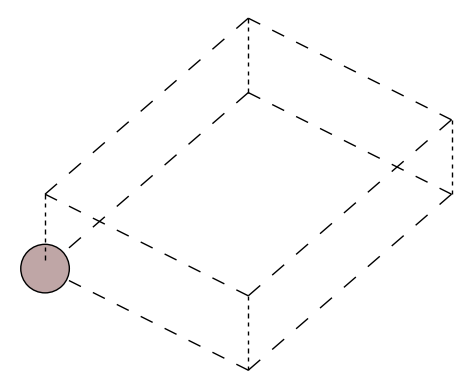

In [19]:
from ase.build import bulk
from ase.calculators.emt import EMT
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

al = bulk('Al', 'fcc', a=4.05)

fig, ax = plt.subplots()
plot_atoms(al, ax, show_unit_cell = 2, radii=0.2, rotation=('30x,0y,0z'))

We then attach the EMT calculator. `atoms.calc = Calculator()`. 

In [8]:
al.calc = EMT()

After that, any call to `get_potential_energy()` or `get_forces()` will trigger an EMT calculation.

In [9]:
# Compute properties
energy = al.get_potential_energy()
forces = al.get_forces()
stress = al.get_stress()

print(f"Energy:  {energy:.4f} eV")
print(f"Forces (should be ~0 at equilibrium):\n{forces}")

Energy:  -0.0015 eV
Forces (should be ~0 at equilibrium):
[[-4.85722573e-16  1.54418765e-15 -3.64263554e-15]]


### Discussion

Do you think this structure at equilibrium?

## Equation of State

Now we use the EMT calculator to find the relationship between volume and energy. We will then fit the Birch-Murnaghan equation of state to extract the equilibrium lattice constant and bulk modulus.

First, use a `for` loop to create contracted and expanded aluminium structures. For each structure calculate and store the volume and energy

In [10]:
volumes, energies = [], []
a0 = 4.05
for scale in np.linspace(0.94, 1.06, 15):
    al_scaled = bulk('Al', 'fcc', a=a0 * scale)
    al_scaled.calc = EMT()
    volumes.append(al_scaled.get_volume())
    energies.append(al_scaled.get_potential_energy())

Now we create an ASE `EquationofState` object. This is used to fit the volumes and energies, and plot the result.

Equilibrium volume V₀ = 15.947 Å³
Equilibrium energy E₀ = -0.0042 eV
Bulk modulus B = 1385365040005484066009070171703094542336.0 GPa
Equilibrium lattice parameter a₀= = 2.517 Å


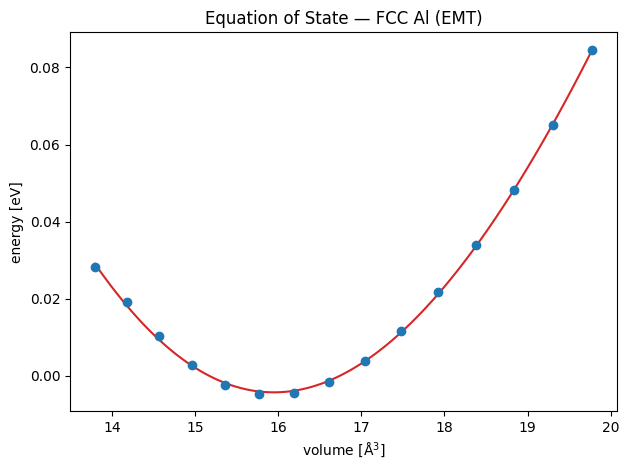

In [21]:
from ase.eos import EquationOfState

# Fit a Birch-Murnaghan EOS
eos = EquationOfState(volumes, energies, eos='birchmurnaghan')
v0, e0, B = eos.fit()

print(f"Equilibrium volume V₀ = {v0:.3f} Å³")
print(f"Equilibrium energy E₀ = {e0:.4f} eV")
print(f"Bulk modulus B = {B / 1.6022e-19 * 1e30 * 1e-9:.1f} GPa")

fig = eos.plot(show=False)
plt.title('Equation of State — FCC Al (EMT)')
plt.tight_layout()
plt.show()


We can use the equilibrium volume to calculate an equilibrium lattice parameter, and compare this to the one we originally provided when creating the aluminium structure:

In [30]:
print(f"Equilibrium lattice parameter a₀= = {v0**(1/3):.3f} Å")
print(f"Starting lattice parameter a₀= = {al.cell.cellpar()[0]:.3f} Å")

Equilibrium lattice parameter a₀= = 2.517 Å
Starting lattice parameter a₀= = 2.864 Å


### Discussion

Why is the starting lattice parameter printed above (a₀= = 2.864 Å) different from the one we specified when creating the aluminium structure with `al = bulk('Al', 'fcc', a=4.05)`?

The curve above looks very much like a polynomial. So let's try fitting a third-order polynomial to the E-V data, and plot the result.

Text(0, 0.5, 'energy [eV]')

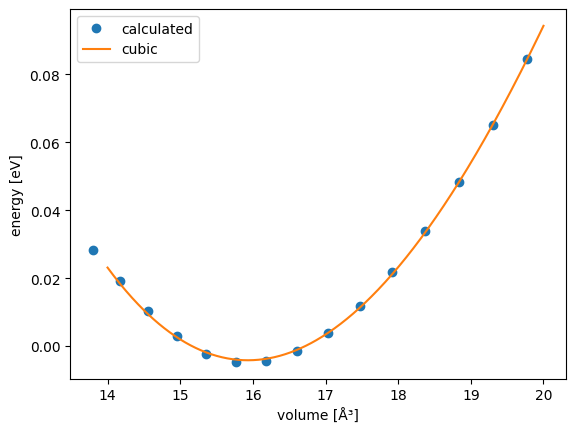

In [47]:
from numpy.polynomial import Polynomial

fit = Polynomial.fit(volumes, energies, 3)

x = np.linspace(14., 20., 500)

plt.plot(volumes, energies, 'o', label='calculated')
plt.plot(x, fit(x), '-', label='cubic')
plt.legend()
plt.xlabel('volume [Å³]')
plt.ylabel('energy [eV]')

The equilibrium lattice parameter can be calculated by finding the volume at which the energy is minimum. We can do this by taking the derivative of the function and finding the roots.

In [54]:
dfit = fit.deriv()
roots = dfit.roots()
print(roots)

[15.93141807 36.05562954]


From inspection of the above plot, we know that the first root is the one we are after. The lattice parameter is the cube root:

In [56]:
print(f"Equilibrium lattice parameter from polynomia a₀= {roots[0]**(1/3):.3f} Å")

Equilibrium lattice parameter from polynomia a₀= 2.516 Å


### Equation of state for nickel

Compute the equation of state for nickel using EMT and extract the bulk modulus. Compare to an experimental value from a reliable online source. 

### Equation of state for diamond

Compute the equation of state for diamond carbon using EMT and extract the bulk modulus. Compare to an experimental value from a reliable online source. Why might this prediction be less accurate than that for nickel?

## Storing Results with ASE Database

The **ASE database** (`ase.db`) is a lightweight SQLite-based database for storing atoms and their calculated properties. It's excellent for managing data across many calculations.

First let's create a dictionary of structures:

In [35]:
structures = {
    'Al': bulk('Al', 'fcc', a=4.05),
    'C_diamond': bulk('C', 'diamond', a=3.57),
}

Now create a database; this will hold the structures and their calculated properties.

In [41]:
import ase.db

# Create a database
db = ase.db.connect('Lab5_materials.db')

Now we iterate through each structure, calculate the corresponding energy using the `EMT` calculator, and write the result to the database. Energy is often calculated as energy per atom, as this is an intensive property which can be compared across calculations (as it is independent of the size of the unit cell).

In [42]:
for name, atoms in structures.items():
    atoms.calc = EMT()
    energy = atoms.get_potential_energy()
    db.write(atoms, name=name,
             energy_per_atom=energy/len(atoms))

We query the database to get properties:

In [43]:
for row in db.select():
    print(f"  {row.name:12s}: E/atom = {row.energy_per_atom:.4f} eV, "
          f"formula = {row.formula}")

  Al          : E/atom = -0.0015 eV, formula = Al
  C_diamond   : E/atom = 0.1702 eV, formula = C2


Note that we didn't supply a formula when creating the database, but ASE automatically gets this using the atomic structure.